In [1]:
import torch
from torch import Tensor
print(torch.__version__)
torch.manual_seed(42)

2.10.0+cu128


In [2]:
# Install required packages.
import os
os.environ['TORCH'] = torch.__version__

!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install pyg-lib -f https://data.pyg.org/whl/nightly/torch-${TORCH}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 73.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/nightly/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 MB 19.1 MB/s eta 0:00:00
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-mo2kzwgm
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-mo2kzwgm
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit a5b69c37a05561ebb92931b3d586d664a7269585
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch-geometric: filename=torch_geometric-2.8.0-py3-none-an

# Link Prediction on MovieLens

This colab notebook shows how to load a set of `*.csv` files as input and construct a heterogeneous graph from it.
We will then use this dataset as input into a [heterogeneous graph model](https://pytorch-geometric.readthedocs.io/en/latest/notes/heterogeneous.html#hgtutorial), and use it for the task of link prediction.
A few code cells require user input to let the code run through successfully.
If you are stuck on cells that require input, take a look at the fully filled out tutorial [here](https://medium.com/@pytorch_geometric/link-prediction-on-heterogeneous-graphs-with-pyg-6d5c29677c70).

We are going to use the [MovieLens dataset](https://grouplens.org/datasets/movielens/) collected by the GroupLens research group.
This toy dataset describes ratings and tagging activity from MovieLens.
The dataset contains approximately 100k ratings across more than 9k movies from more than 600 users.
We are going to use this dataset to generate two node types holding data for movies and users, respectively, and one edge type connecting users and movies, representing the relation of whether a user has rated a specific movie.

The link prediction task then tries to predict missing ratings, and can, for example, be used to recommend users new movies.

## Heterogeneous Graph Creation

First, we download the dataset to an arbitrary folder (in this case, the current directory):

In [3]:
from torch_geometric.data import download_url, extract_zip
from sklearn.metrics import roc_auc_score

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
extract_zip(download_url(url, '.'), '.')

movies_path = './ml-latest-small/movies.csv'
ratings_path = './ml-latest-small/ratings.csv'

Extracting ./ml-latest-small.zip


Before we create the heterogeneous graph, let’s take a look at the data.

We see that the `movies.csv` file provides two useful columns: `movieId` assigns a unique identifier to each movie, while the `genres` column represent genres of the given movie.
We can make use of this column to define a feature representation that can be easily interpreted by machine learning models.

In [4]:
import pandas as pd
# Load the entire movie data frame into memory:
movies_df = pd.read_csv(movies_path, index_col='movieId')

# Split genres and convert into indicator variables:
genres = movies_df['genres'].str.get_dummies('|')
print(genres[["Action", "Adventure", "Drama", "Horror"]].head())

# Use genres as movie input features:
movie_feat = torch.from_numpy(genres.values).to(torch.float)
assert movie_feat.size() == (9742, 20)  # 20 genres in total.

         Action  Adventure  Drama  Horror
movieId                                  
1             0          1      0       0
2             0          1      0       0
3             0          0      0       0
4             0          0      1       0
5             0          0      0       0


The `ratings.csv` data connects users (as given by `userId`) and movies (as given by `movieId`).
Due to simplicity, we do not make use of the additional `timestamp` and `rating` information.
Here, we first read the `*.csv` file from disk, and create a mapping that maps entry IDs to a consecutive value in the range `{ 0, ..., num_rows - 1 }`.
This is needed as we want our final data representation to be as compact as possible, *e.g.*, the representation of a movie in the first row should be accessible via `x[0]`.

Afterwards, we obtain the final `edge_index` representation of shape `[2, num_ratings]` from `ratings.csv` by merging mapped user and movie indices with the raw indices given by the original data frame.

In [5]:
# Load the entire ratings data frame into memory:
ratings_df = pd.read_csv(ratings_path)

# Create a mapping from unique user indices to range [0, num_user_nodes):
unique_user_id = ratings_df['userId'].unique()
unique_user_id = pd.DataFrame(data={
    'userId': unique_user_id,
    'mappedID': pd.RangeIndex(len(unique_user_id)),
})
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()
# Create a mapping from unique movie indices to range [0, num_movie_nodes):
unique_movie_id = pd.DataFrame(data={
    'movieId': movies_df.index,
    'mappedID': pd.RangeIndex(len(movies_df)),
})
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())

# Perform merge to obtain the edges from users and movies:
ratings_user_id = pd.merge(ratings_df['userId'], unique_user_id,
                            left_on='userId', right_on='userId', how='left')
ratings_user_id = torch.from_numpy(ratings_user_id['mappedID'].values)
ratings_movie_id = pd.merge(ratings_df['movieId'], unique_movie_id,
                            left_on='movieId', right_on='movieId', how='left')
ratings_movie_id = torch.from_numpy(ratings_movie_id['mappedID'].values)

# With this, we are ready to construct our `edge_index` in COO format
# following PyG semantics:
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)

assert edge_index_user_to_movie.size() == (2, 100836)

print()
print("Final edge indices pointing from users to movies:")
print("=================================================")
print(edge_index_user_to_movie)

Mapping of user IDs to consecutive values:
   userId  mappedID
0       1         0
1       2         1
2       3         2
3       4         3
4       5         4

Mapping of movie IDs to consecutive values:
   movieId  mappedID
0        1         0
1        2         1
2        3         2
3        4         3
4        5         4

Final edge indices pointing from users to movies:
tensor([[   0,    0,    0,  ...,  609,  609,  609],
        [   0,    2,    5,  ..., 9462, 9463, 9503]])


With this, we are ready to initialize our `HeteroData` object and pass the necessary information to it.
Note that we also pass in a `node_id` vector to each node type in order to reconstruct the original node indices from sampled subgraphs.
We also take care of adding reverse edges to the `HeteroData` object.
This allows our GNN model to use both directions of the edge for message passing:

In [6]:
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

data = HeteroData()

# Save node indices:
data["user"].node_id = torch.arange(len(unique_user_id))
data["movie"].node_id = torch.arange(len(movies_df))

# Add the node features and edge indices:
data["movie"].x = movie_feat
data["user", "rates", "movie"].edge_index = edge_index_user_to_movie

ratings = torch.tensor(ratings_df['rating'].values, dtype=torch.float).view(-1, 1)
data["user", "rates", "movie"].edge_attr = ratings
# ratings should already exist (user_indices, movie_indices, ratings)


data = T.ToUndirected(merge=False)(data)

print(data)

assert data.node_types == ["user", "movie"]
assert data.edge_types == [("user", "rates", "movie"),
                           ("movie", "rev_rates", "user")]
assert data["user"].num_nodes == 610
assert data["user"].num_features == 0
assert data["movie"].num_nodes == 9742
assert data["movie"].num_features == 20
assert data["user", "rates", "movie"].num_edges == 100836
assert data["movie", "rev_rates", "user"].num_edges == 100836

HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 100836],
    edge_attr=[100836, 1],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 100836],
    edge_attr=[100836, 1],
  }
)


## Defining Edge-level Training Splits

Since our data is now ready-to-be-used, we can split the ratings of users into training, validation, and test splits.
This is needed in order to ensure that we leak no information about edges used during evaluation into the training phase.
For this, we make use of the [`transforms.RandomLinkSplit`](https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html#torch_geometric.transforms.RandomLinkSplit) transformation from PyG.
This transforms randomly divides the edges in the `("user", "rates", "movie")` into training, validation and test edges.
The `disjoint_train_ratio` parameter further separates edges in the training split into edges used for message passing (`edge_index`) and edges used for supervision (`edge_label_index`).
Note that we also need to specify the reverse edge type `("movie", "rev_rates", "user")`.
This allows the `RandomLinkSplit` transform to drop reverse edges accordingly to not leak any information into the training phase.

In [7]:
# For this, we first split the set of edges into
# training (80%), validation (10%), and testing edges (10%).
# Across the training edges, we use 70% of edges for message passing,
# and 30% of edges for supervision.
# We further want to generate fixed negative edges for evaluation with a ratio of 2:1.
# Negative edges during training will be generated on-the-fly, so we don't want to
# add them to the graph right away.
# Overall, we can leverage the `RandomLinkSplit()` transform for this from PyG:
transform = T.RandomLinkSplit(
    num_val=0.1,  # TODO
    num_test=0.1,  # TODO
    disjoint_train_ratio=0.3,  # TODO
    neg_sampling_ratio=2.0,  # TODO
    add_negative_train_samples=False,  # TODO
    edge_types=("user", "rates", "movie"),
    rev_edge_types=("movie", "rev_rates", "user"),
)

train_data, val_data, test_data = transform(data)

print("Training data:")
print("==============")
print(train_data)
print()
print("Validation data:")
print("================")
print(val_data)

assert train_data["user", "rates", "movie"].num_edges == 56469
assert train_data["user", "rates", "movie"].edge_label_index.size(1) == 24201
assert train_data["movie", "rev_rates", "user"].num_edges == 56469
# No negative edges added:
assert train_data["user", "rates", "movie"].edge_label.min() == 1
assert train_data["user", "rates", "movie"].edge_label.max() == 1

assert val_data["user", "rates", "movie"].num_edges == 80670
assert val_data["user", "rates", "movie"].edge_label_index.size(1) == 30249
assert val_data["movie", "rev_rates", "user"].num_edges == 80670
# Negative edges with ratio 2:1:
assert val_data["user", "rates", "movie"].edge_label.long().bincount().tolist() == [20166, 10083]

Training data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 56469],
    edge_attr=[56469, 1],
    edge_label=[24201],
    edge_label_index=[2, 24201],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 56469],
    edge_attr=[56469, 1],
  }
)

Validation data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 80670],
    edge_attr=[80670, 1],
    edge_label=[30249],
    edge_label_index=[2, 30249],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 80670],
    edge_attr=[80670, 1],
  }
)


In [8]:
def print_stats(name, data):
    edge_store = data["user", "rates", "movie"]

    num_edges = edge_store.edge_index.size(1)
    num_labels = edge_store.edge_label.size(0)

    labels = edge_store.edge_label.long()
    counts = labels.bincount(minlength=2)

    num_neg = int(counts[0])
    num_pos = int(counts[1])

    print(f"\n{name} DATASET")
    print("-" * 40)
    print(f"Message Passing Edges: {num_edges}")
    print(f"Supervision Edges: {num_labels}")
    print(f"Positive Edges: {num_pos}")
    print(f"Negative Edges: {num_neg}")
    print(f"Pos:Neg Ratio: {num_pos}:{num_neg}")


print_stats("TRAIN", train_data)
print_stats("VALIDATION", val_data)
print_stats("TEST", test_data)


TRAIN DATASET
----------------------------------------
Message Passing Edges: 56469
Supervision Edges: 24201
Positive Edges: 24201
Negative Edges: 0
Pos:Neg Ratio: 24201:0

VALIDATION DATASET
----------------------------------------
Message Passing Edges: 80670
Supervision Edges: 30249
Positive Edges: 10083
Negative Edges: 20166
Pos:Neg Ratio: 10083:20166

TEST DATASET
----------------------------------------
Message Passing Edges: 90753
Supervision Edges: 30249
Positive Edges: 10083
Negative Edges: 20166
Pos:Neg Ratio: 10083:20166


## Defining Mini-batch Loaders

We are now ready to create a mini-batch loader that will generate subgraphs that can be used as input into our GNN.
While this step is not strictly necessary for small-scale graphs, it is absolutely necessary to apply GNNs on larger graphs that do not fit onto GPU memory otherwise.
Here, we make use of the [`loader.LinkNeighborLoader`](https://pytorch-geometric.readthedocs.io/en/latest/modules/loader.html#torch_geometric.loader.LinkNeighborLoader) which samples multiple hops from both ends of a link and creates a subgraph from it.
Here, `edge_label_index` serves as the "seed links" to start sampling from.

In [9]:
# In the first hop, we sample at most 20 neighbors.
# In the second hop, we sample at most 10 neighbors.
# In addition, during training, we want to sample negative edges on-the-fly with
# a ratio of 2:1.
# We can make use of the `loader.LinkNeighborLoader` from PyG:
from torch_geometric.loader import LinkNeighborLoader

# Define seed edges:
edge_label_index = train_data["user", "rates", "movie"].edge_label_index
edge_label = train_data["user", "rates", "movie"].edge_label

train_loader = LinkNeighborLoader(
    data=train_data,  # TODO
    num_neighbors=[20 ,10],  # TODO
    neg_sampling_ratio=2.0,  # TODO
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(
        ("user", "rates", "movie"),
        val_data["user", "rates", "movie"].edge_label_index,
    ),
    edge_label=val_data["user", "rates", "movie"].edge_label,
    batch_size=128,
    shuffle=False,
)

# Inspect a sample:
sampled_data = next(iter(train_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() == 0
assert sampled_data["user", "rates", "movie"].edge_label.max() == 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[606],
    n_id=[606],
    num_sampled_nodes=[3],
  },
  movie={
    node_id=[2819],
    x=[2819, 20],
    n_id=[2819],
    num_sampled_nodes=[3],
  },
  (user, rates, movie)={
    edge_index=[2, 17321],
    edge_attr=[17321, 1],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[17321],
    num_sampled_edges=[2],
    input_id=[128],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7781],
    edge_attr=[7781, 1],
    e_id=[7781],
    num_sampled_edges=[2],
  }
)


## Creating a Heterogeneous Link-level GNN

We are now ready to create our heterogeneous GNN.
The GNN is responsible for learning enriched node representations from the surrounding subgraphs, which can be then used to derive edge-level predictions.
For defining our heterogenous GNN, we make use of [`nn.SAGEConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.SAGEConv) and the [`nn.to_hetero()`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.to_hetero_transformer.to_hetero) function, which transforms a GNN defined on homogeneous graphs to be applied on heterogeneous ones.

In addition, we define a final link-level classifier, which simply takes both node embeddings of the link we are trying to predict, and applies a dot-product on them.

As users do not have any node-level information, we choose to learn their features jointly via a `torch.nn.Embedding` layer. In order to improve the expressiveness of movie features, we do the same for movie nodes, and simply add their shallow embeddings to the pre-defined genre features.

In [10]:
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.nn import MessagePassing
import torch.nn.functional as F
import torch

class RatingAwareConv(MessagePassing):
    def __init__(self, hidden_channels):
        super().__init__(aggr='mean')
        self.lin = torch.nn.Linear(hidden_channels, hidden_channels)

    def forward(self, x_src, x_dst, edge_index, edge_attr):
        return self.propagate(edge_index, x=(x_src, x_dst), edge_attr=edge_attr)

    def message(self, x_j, edge_attr):
        weight = 1 + edge_attr
        return x_j * weight

    def update(self, aggr_out, x):
        x_dst = x[1]   # destination node features (movies)
        return self.lin(aggr_out + x_dst)

class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()

        self.conv1 = RatingAwareConv(hidden_channels)
        self.conv2 = RatingAwareConv(hidden_channels)

    def forward(self, x_dict, edge_index, edge_attr):

        # reverse edges (movie → user)
        rev_edge_index = torch.stack([edge_index[1], edge_index[0]], dim=0)

        # ----- layer 1 -----
        movie_emb = self.conv1(x_dict["user"], x_dict["movie"], edge_index, edge_attr)
        movie_emb = F.relu(movie_emb)

        user_emb = self.conv1(x_dict["movie"], x_dict["user"], rev_edge_index, edge_attr)
        user_emb = F.relu(user_emb)

        # ----- layer 2 -----
        movie_emb = self.conv2(user_emb, movie_emb, edge_index, edge_attr)
        user_emb = self.conv2(movie_emb, user_emb, rev_edge_index, edge_attr)

        return {
            "user": user_emb,
            "movie": movie_emb
        }
# Our final classifier applies the dot-product between source and destination
# node embeddings to derive edge-level predictions:

class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # Since the dataset does not come with rich features, we also learn two
        # embedding matrices for users and movies:
        self.movie_lin = torch.nn.Linear(20, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)
        self.edge_lin = torch.nn.Linear(1,1)
        # Instantiate homogeneous GNN:
        self.gnn = GNN(hidden_channels)




    def forward(self, data: HeteroData) -> Tensor:
        x_dict = {
          "user": self.user_emb(data["user"].node_id),
          "movie": self.movie_lin(data["movie"].x) + self.movie_emb(data["movie"].node_id),
        }

        # `x_dict` holds feature matrices of all node types
        # `edge_index_dict` holds all edge indices of all edge types
        edge_attr_dict = {
            ("user", "rates", "movie"): data["user", "rates", "movie"].edge_attr
        }

        edge_index = data["user", "rates", "movie"].edge_index
        edge_attr = data["user", "rates", "movie"].edge_attr

        x_dict = self.gnn(x_dict, edge_index, edge_attr)

        edge_index = data["user", "rates", "movie"].edge_label_index

        # Node embeddings
        edge_feat_user = x_dict["user"][edge_index[0]]
        edge_feat_movie = x_dict["movie"][edge_index[1]]
        edge_feat_user = F.normalize(edge_feat_user, dim=-1)
        edge_feat_movie = F.normalize(edge_feat_movie, dim=-1)

        # Node similarity
        pred = (edge_feat_user * edge_feat_movie).sum(dim=-1)

        # Edge features

        edge_index = data["user", "rates", "movie"].edge_label_index

        # Get edge_attr ONLY for these edges
        # Number of prediction edges in batch
        num_edges = data["user", "rates", "movie"].edge_label_index.size(1)

        # Dummy edge features (safe fix)
        edge_attr = torch.zeros(num_edges, 1, device=pred.device)

        edge_attr = self.edge_lin(edge_attr).view(-1)

        pred = pred + edge_attr

        return pred


model = Model(hidden_channels=64)

print(model)

Model(
  (movie_lin): Linear(in_features=20, out_features=64, bias=True)
  (user_emb): Embedding(610, 64)
  (movie_emb): Embedding(9742, 64)
  (edge_lin): Linear(in_features=1, out_features=1, bias=True)
  (gnn): GNN(
    (conv1): RatingAwareConv()
    (conv2): RatingAwareConv()
  )
)


In [11]:
num_users = data["user"].num_nodes
num_movies = data["movie"].num_nodes

total_possible = num_users * num_movies
actual_edges = data["user", "rates", "movie"].edge_index.size(1)

print("\nGLOBAL GRAPH INFO")
print("-" * 40)
print(f"Users: {num_users}")
print(f"Movies: {num_movies}")
print(f"Possible edges: {total_possible}")
print(f"Actual edges: {actual_edges}")
print(f"Sparsity: {actual_edges / total_possible:.6f}")


GLOBAL GRAPH INFO
----------------------------------------
Users: 610
Movies: 9742
Possible edges: 5942620
Actual edges: 100836
Sparsity: 0.016968


## Training a Heterogeneous Link-level GNN

Training our GNN is then similar to training any PyTorch model.
We move the model to the desired device, and initialize an optimizer that takes care of adjusting model parameters via stochastic gradient descent.

The training loop then iterates over our mini-batches, applies the forward computation of the model, computes the loss from ground-truth labels and obtained predictions (here we make use of binary cross entropy), and adjusts model parameters via back-propagation and stochastic gradient descent.

In [12]:
import tqdm
import torch.nn.functional as F
import numpy as np
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")

model = Model(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses = []
val_aucs = []
LOSS_TYPE = "bpr"   # options: "bce", "mse", "bpr"
for epoch in range(1, 31):
    model.train()
    total_loss = total_examples = 0

    for sampled_data in train_loader:
        sampled_data = sampled_data.to(device)

        optimizer.zero_grad()
        pred = model(sampled_data)

        ground_truth = sampled_data["user", "rates", "movie"].edge_label.float()

        if LOSS_TYPE == "bce":
            loss = F.binary_cross_entropy_with_logits(pred, ground_truth)

        elif LOSS_TYPE == "mse":
            pred_prob = torch.sigmoid(pred)
            loss = F.mse_loss(pred_prob, ground_truth)

        elif LOSS_TYPE == "bpr":
            pos_mask = ground_truth == 1
            neg_mask = ground_truth == 0

            pos_scores = pred[pos_mask]
            neg_scores = pred[neg_mask]

            # Handle edge case
            if len(pos_scores) == 0 or len(neg_scores) == 0:
                continue

    # Match sizes
            min_len = min(len(pos_scores), len(neg_scores))
            pos_scores = pos_scores[:min_len]
            neg_scores = neg_scores[:min_len]

            loss = -torch.log(torch.sigmoid(pos_scores - neg_scores)).mean()
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item() * pred.numel()
        total_examples += pred.numel()

    avg_loss = total_loss / total_examples
    train_losses.append(avg_loss)

    # ---- VALIDATION ----
    model.eval()
    preds, gts = [], []

    for sampled_data in val_loader:
        sampled_data = sampled_data.to(device)
        with torch.no_grad():
            pred = torch.sigmoid(model(sampled_data))

        gt = sampled_data["user", "rates", "movie"].edge_label.float()
        preds.append(pred)
        gts.append(gt)

    pred_all = torch.cat(preds).cpu().numpy()
    gt_all = torch.cat(gts).cpu().numpy()

    auc = roc_auc_score(gt_all, pred_all)
    val_aucs.append(auc)

    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}, Val AUC: {auc:.4f}")

Device: 'cuda'
Epoch 1, Loss: 0.4944, Val AUC: 0.8508
Epoch 2, Loss: 0.3989, Val AUC: 0.8774
Epoch 3, Loss: 0.3707, Val AUC: 0.8908
Epoch 4, Loss: 0.3555, Val AUC: 0.8986
Epoch 5, Loss: 0.3470, Val AUC: 0.9012
Epoch 6, Loss: 0.3427, Val AUC: 0.9051
Epoch 7, Loss: 0.3400, Val AUC: 0.9078
Epoch 8, Loss: 0.3357, Val AUC: 0.9045
Epoch 9, Loss: 0.3334, Val AUC: 0.8989
Epoch 10, Loss: 0.3335, Val AUC: 0.9071
Epoch 11, Loss: 0.3298, Val AUC: 0.9084
Epoch 12, Loss: 0.3287, Val AUC: 0.9027
Epoch 13, Loss: 0.3275, Val AUC: 0.9006
Epoch 14, Loss: 0.3272, Val AUC: 0.9097
Epoch 15, Loss: 0.3236, Val AUC: 0.9078
Epoch 16, Loss: 0.3247, Val AUC: 0.9064
Epoch 17, Loss: 0.3224, Val AUC: 0.9086
Epoch 18, Loss: 0.3198, Val AUC: 0.8997
Epoch 19, Loss: 0.3213, Val AUC: 0.9074
Epoch 20, Loss: 0.3210, Val AUC: 0.9116
Epoch 21, Loss: 0.3195, Val AUC: 0.9056
Epoch 22, Loss: 0.3189, Val AUC: 0.9077
Epoch 23, Loss: 0.3156, Val AUC: 0.9059
Epoch 24, Loss: 0.3179, Val AUC: 0.9086
Epoch 25, Loss: 0.3185, Val AUC: 0

## Evaluating a Heterogeneous Link-level GNN

After training, we evaluate our model on useen data coming from the validation set.
For this, we define a new `LinkNeighborLoader` (which now iterates over the edges in the validation set), obtain the predictions on validation edges by running the model, and finally evaluate the performance of the model by computing the AUC score over the set of predictions and their corresponding ground-truth edges (including both positive and negative edges).

In [13]:
# Define the validation seed edges:
edge_label_index = val_data["user", "rates", "movie"].edge_label_index
edge_label = val_data["user", "rates", "movie"].edge_label

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

sampled_data = next(iter(val_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() >= 0
assert sampled_data["user", "rates", "movie"].edge_label.max() <= 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[608],
    n_id=[608],
    num_sampled_nodes=[3],
  },
  movie={
    node_id=[2707],
    x=[2707, 20],
    n_id=[2707],
    num_sampled_nodes=[3],
  },
  (user, rates, movie)={
    edge_index=[2, 19325],
    edge_attr=[19325, 1],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[19325],
    num_sampled_edges=[2],
    input_id=[384],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7821],
    edge_attr=[7821, 1],
    e_id=[7821],
    num_sampled_edges=[2],
  }
)


In [14]:
from sklearn.metrics import roc_auc_score

preds = []
ground_truths = []
for sampled_data in tqdm.tqdm(val_loader):
    with torch.no_grad():
        sampled_data = sampled_data.to(device)



        pred = model(sampled_data)
        pred = torch.sigmoid(pred)
        ground_truth = sampled_data["user", "rates", "movie"].edge_label
        preds.append(pred)
        ground_truths.append(ground_truth)

pred = torch.cat(preds, dim=0).cpu().numpy()
ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
auc = roc_auc_score(ground_truth, pred)
print()
print(f"Validation AUC: {auc:.4f}")

100%|██████████| 79/79 [00:00<00:00, 165.37it/s]


Validation AUC: 0.9024


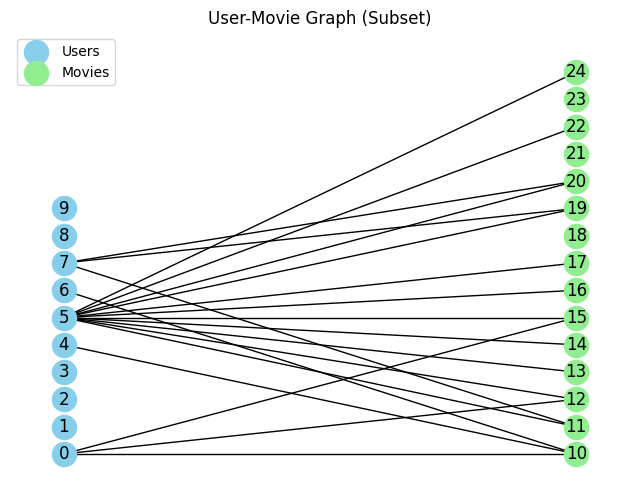

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

# Take a SMALL subset for visualization
num_users = 10
num_movies = 15

edge_index = data["user", "rates", "movie"].edge_index

# Filter edges to small subset
edges = []
for u, m in zip(edge_index[0], edge_index[1]):
    if u < num_users and m < num_movies:
        edges.append((int(u), int(m)))

# Create graph
G = nx.Graph()

# Add user nodes
for u in range(num_users):
    G.add_node(u, node_type='user')

# Add movie nodes (offset)
movie_offset = num_users
for m in range(num_movies):
    G.add_node(m + movie_offset, node_type='movie')

# Add edges
for u, m in edges:
    G.add_edge(u, m + movie_offset)

# Position nodes
pos = {}

# Users (left)
for u in range(num_users):
    pos[u] = (0, u)

# Movies (right)
for m in range(num_movies):
    pos[m + movie_offset] = (1, m)

# Separate nodes
user_nodes = [n for n in G.nodes if n < movie_offset]
movie_nodes = [n for n in G.nodes if n >= movie_offset]

# Plot
plt.figure(figsize=(8,6))

nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color='skyblue', label='Users')
nx.draw_networkx_nodes(G, pos, nodelist=movie_nodes, node_color='lightgreen', label='Movies')

nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

plt.title("User-Movie Graph (Subset)")
plt.legend()
plt.axis('off')
plt.show()

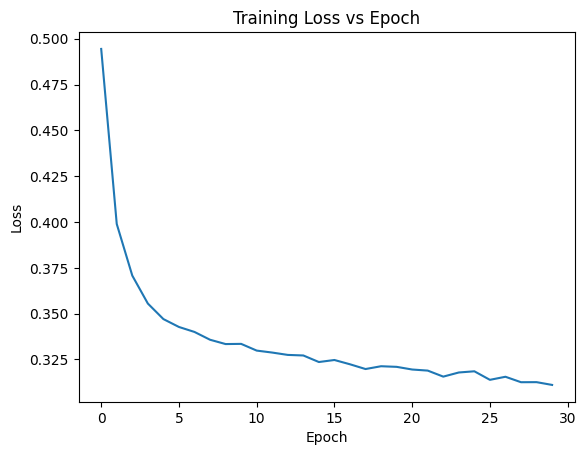

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.show()

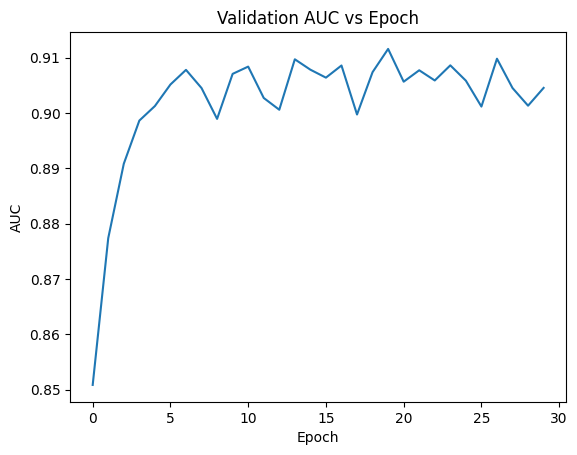

In [17]:
plt.figure()
plt.plot(val_aucs)
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC vs Epoch")
plt.show()

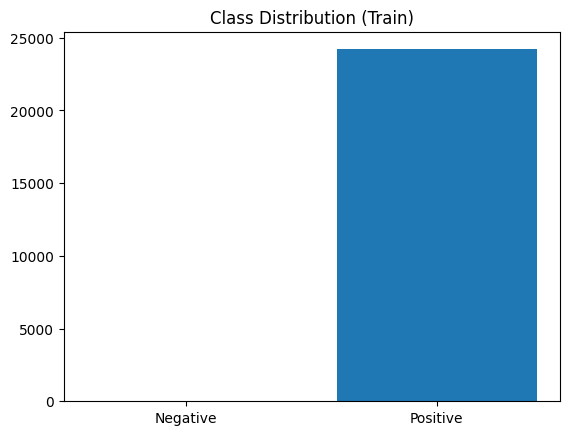

In [18]:
import numpy as np

labels = train_data["user", "rates", "movie"].edge_label.cpu().numpy()

counts = np.bincount(labels.astype(int))

plt.figure()
plt.bar(["Negative", "Positive"], counts)
plt.title("Class Distribution (Train)")
plt.show()

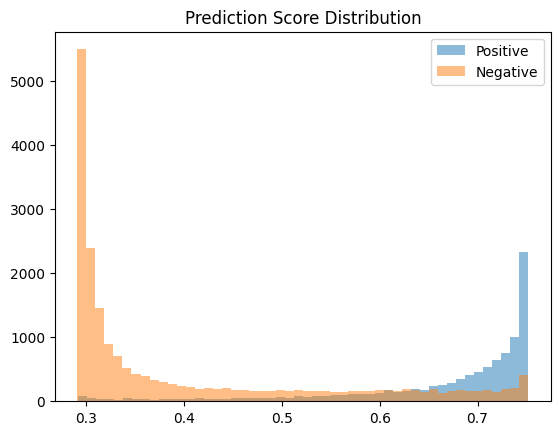

In [19]:
plt.figure()

pos_scores = pred_all[gt_all == 1]
neg_scores = pred_all[gt_all == 0]

plt.hist(pos_scores, bins=50, alpha=0.5, label="Positive")
plt.hist(neg_scores, bins=50, alpha=0.5, label="Negative")

plt.legend()
plt.title("Prediction Score Distribution")
plt.show()

In [20]:
test_loader = LinkNeighborLoader(
    data=test_data,
    num_neighbors=[20, 10],
    edge_label_index=(
        ("user", "rates", "movie"),
        test_data["user", "rates", "movie"].edge_label_index,
    ),
    edge_label=test_data["user", "rates", "movie"].edge_label,
    batch_size=128,
    shuffle=False,
)

In [21]:
model.eval()
preds, gts = [], []

with torch.no_grad():
    for sampled_data in test_loader:
        sampled_data = sampled_data.to(device)

        pred = torch.sigmoid(model(sampled_data))
        gt = sampled_data["user", "rates", "movie"].edge_label.float()

        preds.append(pred)
        gts.append(gt)

pred_all = torch.cat(preds).cpu().numpy()
gt_all = torch.cat(gts).cpu().numpy()

from sklearn.metrics import roc_auc_score
test_auc = roc_auc_score(gt_all, pred_all)

print("Final Test AUC:", test_auc)

Final Test AUC: 0.9032801254496928


In [22]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import torch.nn.functional as F

def visualize_test_subgraph(model, test_loader, device):

    model.eval()

    # 👉 take ONE batch (subgraph)
    sampled_data = next(iter(test_loader))
    sampled_data = sampled_data.to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(sampled_data))

    gt = sampled_data["user", "rates", "movie"].edge_label.float()

    # convert to cpu
    pred = pred.cpu()
    gt = gt.cpu()

    # threshold
    pred_label = (pred > 0.5).float()

    # correctness
    correct = pred_label == gt

    # 🔥 get embeddings
    with torch.no_grad():
        out = model.gnn(
            {
                "user": model.user_emb(sampled_data["user"].node_id),
                "movie": model.movie_emb(sampled_data["movie"].node_id)
            },
            sampled_data["user", "rates", "movie"].edge_index,
            sampled_data["user", "rates", "movie"].edge_attr
        )

    u_emb = F.normalize(out["user"], dim=-1).cpu().numpy()
    m_emb = F.normalize(out["movie"], dim=-1).cpu().numpy()

    emb = np.vstack([u_emb, m_emb])

    # 🔥 TSNE (safe perplexity)
    n_samples = emb.shape[0]
    perplexity = min(10, n_samples - 1)

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    emb_2d = tsne.fit_transform(emb)

    num_users = u_emb.shape[0]
    u_2d = emb_2d[:num_users]
    m_2d = emb_2d[num_users:]

    # edges used for prediction
    edge_index = sampled_data["user", "rates", "movie"].edge_label_index.cpu()

    plt.figure(figsize=(12,10))

    # nodes
    plt.scatter(u_2d[:,0], u_2d[:,1], c='blue', s=150, label='Users')
    plt.scatter(m_2d[:,0], m_2d[:,1], c='orange', s=150, label='Movies')

    # 🔥 draw edges
    for i in range(edge_index.size(1)):

        u = edge_index[0, i].item()
        m = edge_index[1, i].item()

        if gt[i] == 1:
            color = 'green' if correct[i] else 'red'
        else:
            if correct[i]:
                continue  # correct negative → skip for clarity
            color = 'purple'  # wrong negative

        plt.plot(
            [u_2d[u][0], m_2d[m][0]],
            [u_2d[u][1], m_2d[m][1]],
            color=color,
            alpha=0.7
        )

    plt.title("Test Subgraph Link Prediction\nGreen=Correct, Red=Wrong, Purple=False Positive")
    plt.legend()
    plt.grid(False)
    plt.show()

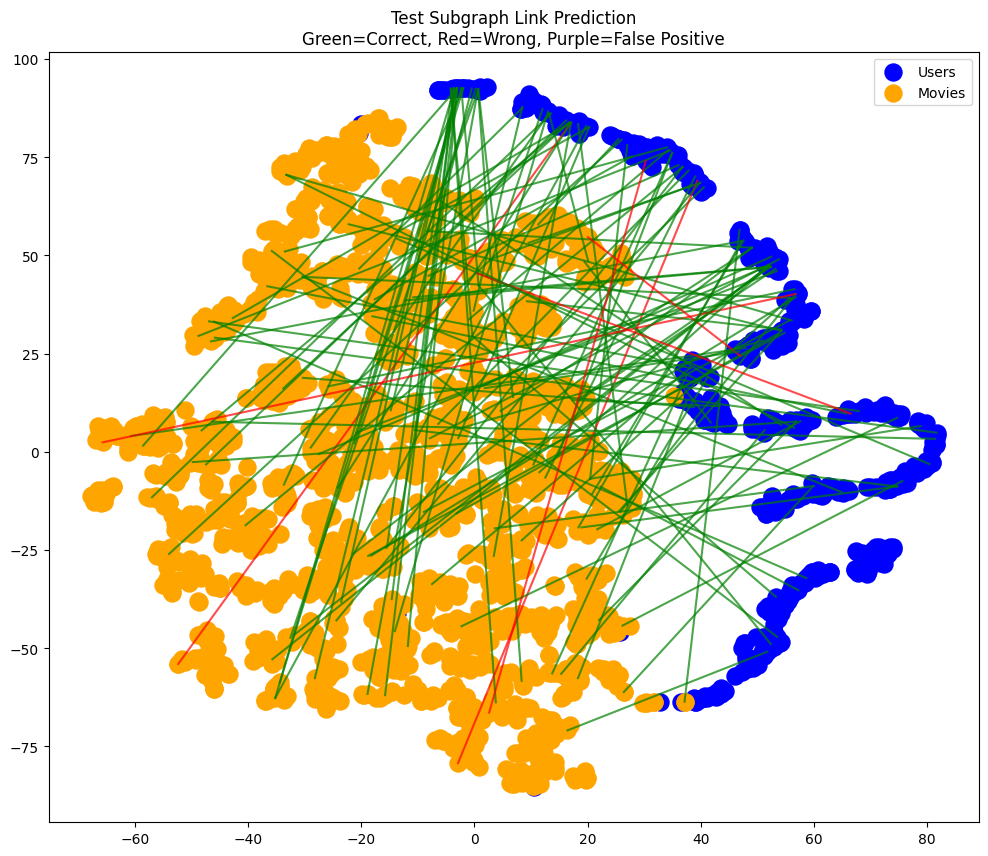

In [23]:
visualize_test_subgraph(model, test_loader, device)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


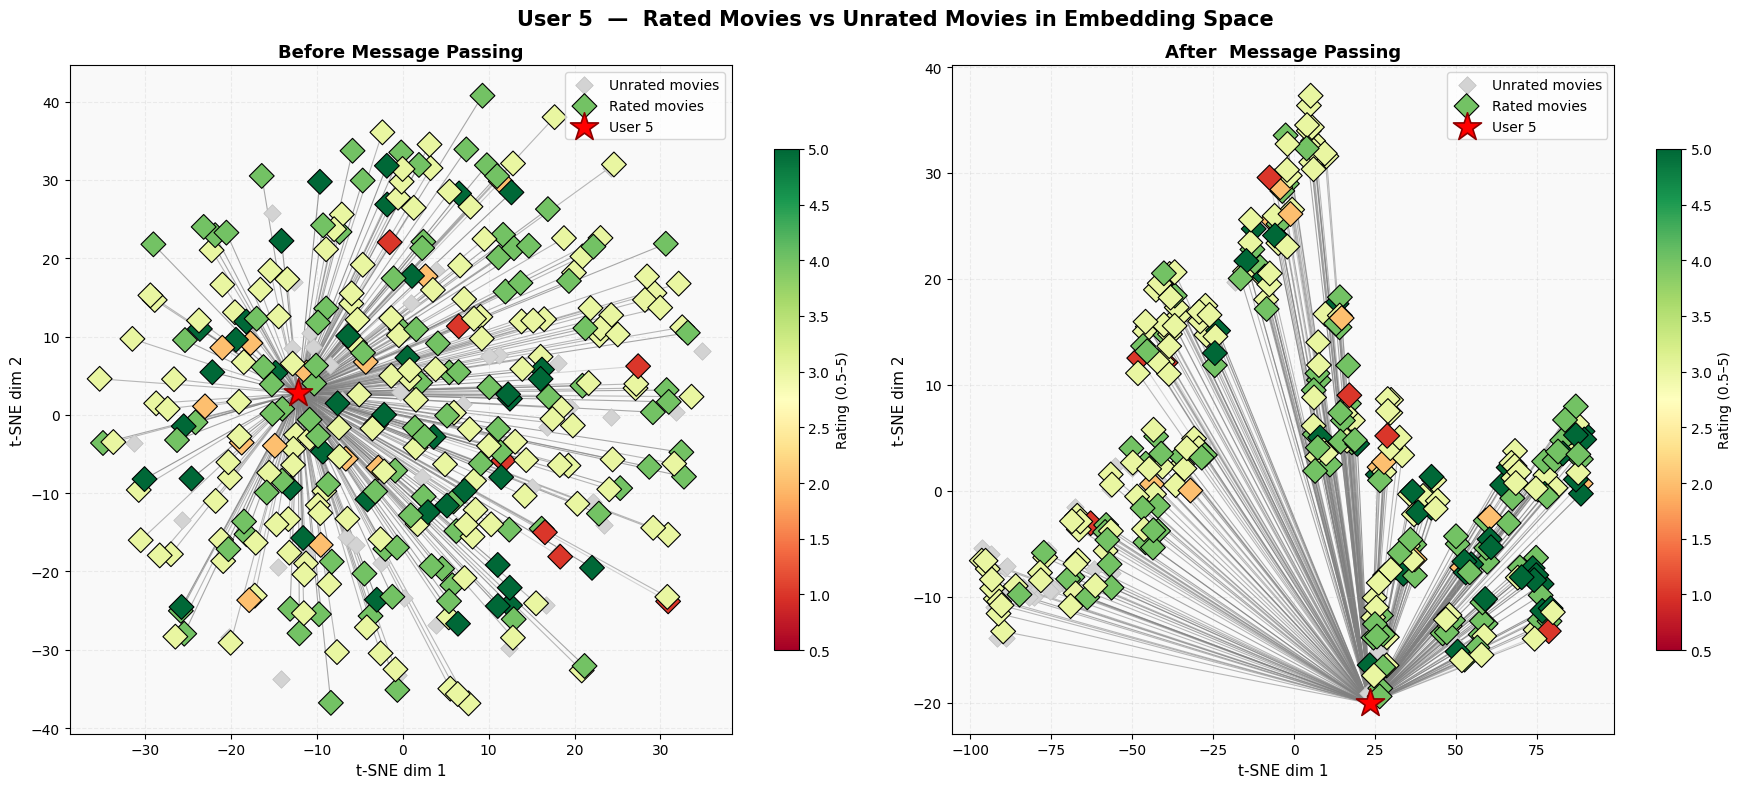

User 5 has rated 314 movies visible in this data split.

  Separation BEFORE MP : +0.0016
  Separation AFTER  MP : +1.0625
  Improvement          : +1.0609  ✅ MP helped!


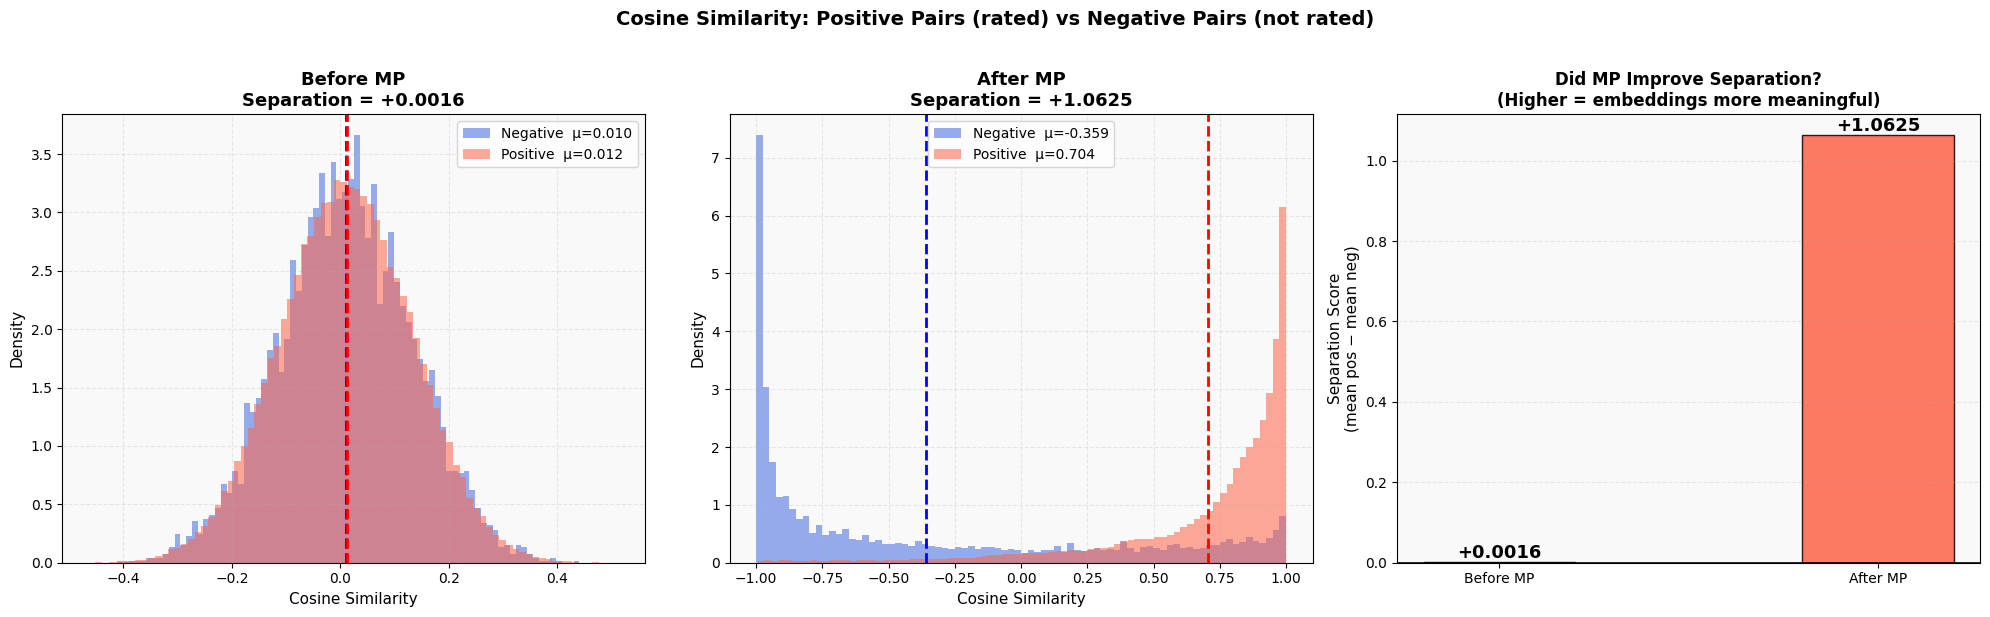


───────────────────────────────────────────────────────
  BEFORE MESSAGE PASSING — Median Ranks
───────────────────────────────────────────────────────
  U0      median rank  4807 / 9742  ( 49.3%)  ████████████████████████
  U1      median rank  4929 / 9742  ( 50.6%)  █████████████████████████
  U2      median rank  5034 / 9742  ( 51.7%)  █████████████████████████
  U3      median rank  4519 / 9742  ( 46.4%)  ███████████████████████
  U4      median rank  4179 / 9742  ( 42.9%)  █████████████████████

───────────────────────────────────────────────────────
  AFTER MESSAGE PASSING — Median Ranks
───────────────────────────────────────────────────────
  U0      median rank   715 / 9742  (  7.3%)  ███
  U1      median rank   278 / 9742  (  2.9%)  █
  U2      median rank  1066 / 9742  ( 10.9%)  █████
  U3      median rank   980 / 9742  ( 10.1%)  █████
  U4      median rank    56 / 9742  (  0.6%)  


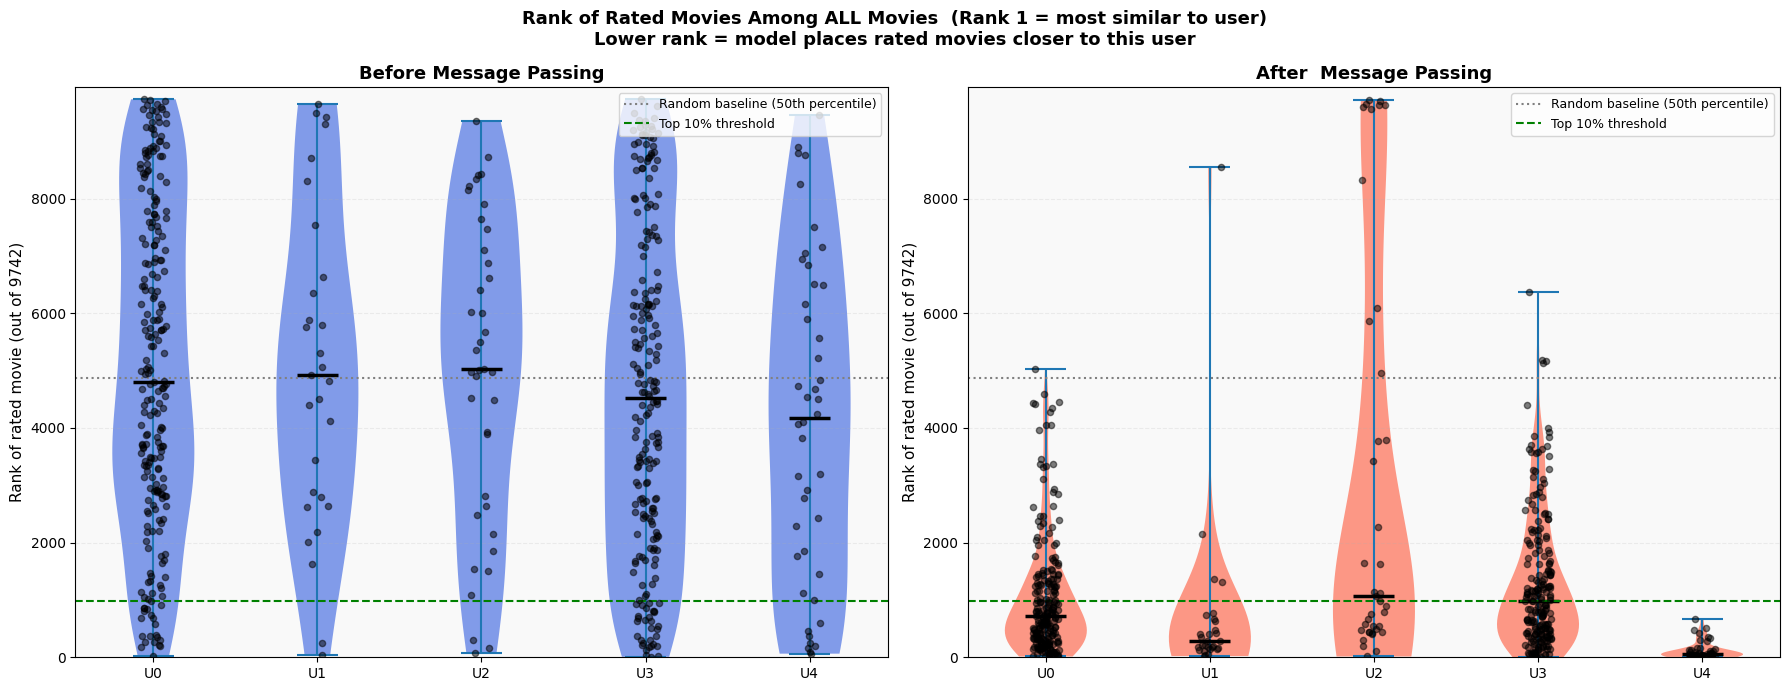

In [24]:
"""
Corrected Embedding Closeness Visualizations — Before vs. After Message Passing
================================================================================

The goal: show that after MP, users and the movies they RATED moved CLOSER,
while users and movies they DIDN'T rate stayed FAR.

Three visualizations that actually demonstrate this:

  1. Per-User t-SNE — one focal user + their rated vs unrated movies
  2. Similarity Score Scatter — dot-product of positive vs negative pairs
  3. Ranked Pull Chart — how much each rated movie "moved toward" the user
"""

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE

# ──────────────────────────────────────────────
# CORE: Extract embeddings before & after GNN
# ──────────────────────────────────────────────

def get_embeddings_before_after(model, data):
    """
    x_before  →  initial representations, no edge info yet
    x_after   →  after RatingAwareConv (ratings on edges shaped these)
    """
    model.eval()
    with torch.no_grad():
        x_before = {
            "user":  model.user_emb(data["user"].node_id),
            "movie": model.movie_lin(data["movie"].x) + model.movie_emb(data["movie"].node_id),
        }
        edge_index = data["user", "rates", "movie"].edge_index
        edge_attr  = data["user", "rates", "movie"].edge_attr
        x_after = model.gnn(
            {k: v.clone() for k, v in x_before.items()},
            edge_index,
            edge_attr,
        )
    return x_before, x_after


# ──────────────────────────────────────────────────────────────────────────────
# VIZ 1 — Per-User t-SNE
# Shows one focal user + their RATED movies (coloured by rating) + random
# UNRATED movies.  The key signal: after MP, rated movies should be pulled
# into the same region of the plot as the user.
# ──────────────────────────────────────────────────────────────────────────────

def plot_per_user_tsne(model, data, user_id=0, num_unrated=30, perplexity=8):
    """
    t-SNE centred on a single user.

    Rated movies    → coloured by their rating (low=cold, high=warm)
    Unrated movies  → grey (random sample)
    Focal user      → large red star

    BEFORE MP: rated and unrated movies are uniformly scattered around the user
    AFTER  MP: movies the user rated highly should cluster near the user star
    """
    x_before, x_after = get_embeddings_before_after(model, data)

    edge_index = data["user", "rates", "movie"].edge_index
    edge_attr  = data["user", "rates", "movie"].edge_attr

    # Find movies this user actually rated
    mask         = edge_index[0] == user_id
    rated_movies = edge_index[1][mask].cpu().numpy()
    ratings      = edge_attr[mask].squeeze(-1).cpu().numpy()

    if len(rated_movies) == 0:
        print(f"User {user_id} has no ratings in this data split. Try a different user_id.")
        return

    # Sample unrated movies
    all_movie_ids  = np.arange(data["movie"].num_nodes)
    unrated_movies = np.setdiff1d(all_movie_ids, rated_movies)
    rng            = np.random.default_rng(42)
    unrated_sample = rng.choice(unrated_movies,
                                size=min(num_unrated, len(unrated_movies)),
                                replace=False)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(
        f"User {user_id}  —  Rated Movies vs Unrated Movies in Embedding Space",
        fontsize=15, fontweight="bold",
    )

    for ax, x_dict, title in [
        (axes[0], x_before, "Before Message Passing"),
        (axes[1], x_after,  "After  Message Passing"),
    ]:
        u_emb = x_dict["user"][user_id].cpu().numpy()      # (D,)
        r_emb = x_dict["movie"][rated_movies].cpu().numpy() # (nr, D)
        u_emb_sample = x_dict["movie"][unrated_sample].cpu().numpy()  # (nu, D)

        # Stack: user | rated movies | unrated movies
        all_pts = np.vstack([u_emb[np.newaxis], r_emb, u_emb_sample])
        n_tot   = all_pts.shape[0]

        perp = min(perplexity, n_tot - 1)
        tsne  = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1500)
        pts2d = tsne.fit_transform(all_pts)

        u_pt     = pts2d[0]
        r_pts    = pts2d[1 : 1 + len(rated_movies)]
        nu_pts   = pts2d[1 + len(rated_movies):]

        # Draw lines from user to each rated movie (weight = rating)
        for i, (rx, ry) in enumerate(r_pts):
            alpha = 0.3 + 0.5 * (ratings[i] - ratings.min()) / (ratings.max() - ratings.min() + 1e-6)
            ax.plot([u_pt[0], rx], [u_pt[1], ry],
                    color="gray", lw=0.8, alpha=alpha, zorder=1)

        # Unrated movies (grey)
        ax.scatter(nu_pts[:, 0], nu_pts[:, 1],
                   c="lightgray", s=80, edgecolors="silver",
                   linewidths=0.5, label="Unrated movies", zorder=2, marker="D")

        # Rated movies (coloured by rating)
        sc = ax.scatter(r_pts[:, 0], r_pts[:, 1],
                        c=ratings, cmap="RdYlGn", vmin=0.5, vmax=5.0,
                        s=160, edgecolors="black", linewidths=0.8,
                        label="Rated movies", zorder=3, marker="D")
        plt.colorbar(sc, ax=ax, label="Rating (0.5–5)", shrink=0.75)

        # Focal user
        ax.scatter(*u_pt, c="red", s=450, marker="*",
                   edgecolors="darkred", linewidths=1.2,
                   label=f"User {user_id}", zorder=4)

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("t-SNE dim 1", fontsize=11)
        ax.set_ylabel("t-SNE dim 2", fontsize=11)
        ax.legend(fontsize=10, loc="upper right")
        ax.grid(True, alpha=0.2, linestyle="--")
        ax.set_facecolor("#f9f9f9")

    plt.tight_layout()
    plt.savefig(f"tsne_user_{user_id}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"User {user_id} has rated {len(rated_movies)} movies visible in this data split.")


# ──────────────────────────────────────────────────────────────────────────────
# VIZ 2 — Similarity Score Distributions: Positive vs Negative Pairs
# The clearest proof that MP made embeddings meaningful:
#   positive pairs (edges that exist) → higher dot-product similarity
#   negative pairs (no edge) → lower dot-product similarity
# The gap between them should WIDEN after MP.
# ──────────────────────────────────────────────────────────────────────────────

def plot_pos_neg_similarity(model, data, num_neg_pairs=5000):
    """
    Compares cosine similarity distributions for:
      • Positive pairs  — (user, movie) where a rating edge EXISTS
      • Negative pairs  — (user, movie) where NO edge exists (randomly sampled)

    Before MP: distributions should strongly overlap (random embeddings)
    After  MP: positive pairs should score higher → distributions separate
               This separation IS the evidence that embeddings became meaningful.

    Also prints a Separation Score = mean(pos) - mean(neg) as a single number.
    """
    x_before, x_after = get_embeddings_before_after(model, data)

    edge_index = data["user", "rates", "movie"].edge_index.cpu()
    num_users  = data["user"].num_nodes
    num_movies = data["movie"].num_nodes

    # Build a set of existing edges for fast lookup
    pos_set = set(zip(edge_index[0].tolist(), edge_index[1].tolist()))

    # Random negative pairs
    rng   = np.random.default_rng(0)
    neg_u = rng.integers(0, num_users,  size=num_neg_pairs * 3)
    neg_m = rng.integers(0, num_movies, size=num_neg_pairs * 3)
    neg_pairs = [(u, m) for u, m in zip(neg_u, neg_m) if (u, m) not in pos_set][:num_neg_pairs]
    neg_u = torch.tensor([p[0] for p in neg_pairs])
    neg_m = torch.tensor([p[1] for p in neg_pairs])

    pos_u = edge_index[0]
    pos_m = edge_index[1]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(
        "Cosine Similarity: Positive Pairs (rated) vs Negative Pairs (not rated)",
        fontsize=14, fontweight="bold", y=1.02,
    )

    sep_scores = {}
    for col, (x_dict, stage) in enumerate([
        (x_before, "Before MP"),
        (x_after,  "After MP"),
    ]):
        u_emb = F.normalize(x_dict["user"],  dim=-1).cpu()
        m_emb = F.normalize(x_dict["movie"], dim=-1).cpu()

        with torch.no_grad():
            pos_sim = (u_emb[pos_u] * m_emb[pos_m]).sum(dim=-1).numpy()
            neg_sim = (u_emb[neg_u] * m_emb[neg_m]).sum(dim=-1).numpy()

        sep = pos_sim.mean() - neg_sim.mean()
        sep_scores[stage] = sep

        ax = axes[col]
        ax.hist(neg_sim, bins=80, alpha=0.55, color="royalblue",
                density=True, label=f"Negative  μ={neg_sim.mean():.3f}")
        ax.hist(pos_sim, bins=80, alpha=0.55, color="tomato",
                density=True, label=f"Positive  μ={pos_sim.mean():.3f}")
        ax.axvline(neg_sim.mean(), color="blue", linestyle="--", linewidth=2)
        ax.axvline(pos_sim.mean(), color="red",  linestyle="--", linewidth=2)
        ax.set_title(f"{stage}\nSeparation = {sep:+.4f}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Cosine Similarity", fontsize=11)
        ax.set_ylabel("Density",           fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.set_facecolor("#f9f9f9")

    # Panel 3: delta between pos and neg, before vs after
    ax = axes[2]
    labels = list(sep_scores.keys())
    values = list(sep_scores.values())
    colors = ["steelblue", "tomato"]
    bars   = ax.bar(labels, values, color=colors, edgecolor="black", alpha=0.85, width=0.4)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + 0.001 if v >= 0 else v - 0.003,
                f"{v:+.4f}", ha="center", va="bottom" if v >= 0 else "top",
                fontsize=13, fontweight="bold")
    ax.axhline(0, color="black", linewidth=1.2)
    ax.set_ylabel("Separation Score\n(mean pos − mean neg)", fontsize=11)
    ax.set_title("Did MP Improve Separation?\n(Higher = embeddings more meaningful)",
                 fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.25, axis="y", linestyle="--")
    ax.set_facecolor("#f9f9f9")

    improvement = sep_scores["After MP"] - sep_scores["Before MP"]
    print(f"\n{'='*50}")
    print(f"  Separation BEFORE MP : {sep_scores['Before MP']:+.4f}")
    print(f"  Separation AFTER  MP : {sep_scores['After MP']:+.4f}")
    print(f"  Improvement          : {improvement:+.4f}  {'✅ MP helped!' if improvement > 0 else '❌ MP did not help separation'}")
    print(f"{'='*50}")

    plt.tight_layout()
    plt.savefig("pos_neg_similarity.png", dpi=150, bbox_inches="tight")
    plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# VIZ 3 — Per-User Ranking Chart
# For each selected user: sort all movies by similarity score.
# Show where their actual RATED movies land in that ranking before vs after MP.
# After MP, rated movies should rank much higher (closer to rank 1).
# ──────────────────────────────────────────────────────────────────────────────

def plot_rating_rank_improvement(model, data, user_ids=None):
    """
    For each user in user_ids:
      - Compute similarity to ALL movies (before and after MP)
      - Rank all movies by similarity (rank 1 = most similar)
      - Record the rank of each movie the user actually RATED

    A good model: rated movies are ranked at the TOP (rank 1-100) after MP.
    A random model: rated movies are scattered uniformly across all ranks.

    The violin plot shows the distribution of rated-movie ranks.
    Median rank dropping from ~5000 to ~500 = embeddings became meaningful.
    """
    if user_ids is None:
        user_ids = list(range(10))

    x_before, x_after = get_embeddings_before_after(model, data)
    edge_index = data["user", "rates", "movie"].edge_index.cpu()
    num_movies = data["movie"].num_nodes

    results = {uid: {"before": [], "after": []} for uid in user_ids}

    for x_dict, stage in [(x_before, "before"), (x_after, "after")]:
        u_emb = F.normalize(x_dict["user"],  dim=-1).cpu()
        m_emb = F.normalize(x_dict["movie"], dim=-1).cpu()

        for uid in user_ids:
            mask         = edge_index[0] == uid
            rated_movies = edge_index[1][mask].tolist()
            if not rated_movies:
                continue

            with torch.no_grad():
                sims  = torch.matmul(u_emb[uid], m_emb.T)  # (num_movies,)
                order = torch.argsort(sims, descending=True).tolist()
                rank_of = {movie_id: rank + 1 for rank, movie_id in enumerate(order)}
                results[uid][stage] = [rank_of[m] for m in rated_movies]

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(
        "Rank of Rated Movies Among ALL Movies  (Rank 1 = most similar to user)\n"
        "Lower rank = model places rated movies closer to this user",
        fontsize=13, fontweight="bold",
    )

    for ax, stage, color, title in [
        (axes[0], "before", "royalblue", "Before Message Passing"),
        (axes[1], "after",  "tomato",    "After  Message Passing"),
    ]:
        data_viol = [results[uid][stage] for uid in user_ids if results[uid][stage]]
        labels    = [f"U{uid}" for uid in user_ids if results[uid][stage]]

        parts = ax.violinplot(data_viol, showmedians=True, showextrema=True)
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.65)
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(2.5)

        # Overlay strip of individual points
        for i, ranks in enumerate(data_viol, start=1):
            jitter = np.random.default_rng(i).uniform(-0.08, 0.08, len(ranks))
            ax.scatter([i + j for j in jitter], ranks,
                       s=20, alpha=0.5, color="black", zorder=3)

        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_ylabel(f"Rank of rated movie (out of {num_movies})", fontsize=11)
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_ylim(0, num_movies + 200)

        # Reference lines
        ax.axhline(num_movies / 2, color="gray",  linestyle=":",
                   linewidth=1.5, label="Random baseline (50th percentile)")
        ax.axhline(num_movies * 0.1, color="green", linestyle="--",
                   linewidth=1.5, label="Top 10% threshold")
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(True, alpha=0.2, axis="y", linestyle="--")
        ax.set_facecolor("#f9f9f9")

        # Print medians
        for lbl, ranks in zip(labels, data_viol):
            med = np.median(ranks)
            pct = 100 * med / num_movies

        print(f"\n{'─'*55}")
        print(f"  {stage.upper()} MESSAGE PASSING — Median Ranks")
        print(f"{'─'*55}")
        for lbl, ranks in zip(labels, data_viol):
            med = np.median(ranks)
            pct = 100 * med / num_movies
            bar = "█" * int(pct / 2)
            print(f"  {lbl:<6}  median rank {int(med):>5} / {num_movies}  ({pct:5.1f}%)  {bar}")

    plt.tight_layout()
    plt.savefig("rating_rank_improvement.png", dpi=150, bbox_inches="tight")
    plt.show()


# ══════════════════════════════════════════════
# RUNNER
# ══════════════════════════════════════════════

def run_all_corrected_visualizations(model, data, user_ids=None):
    """
    Run all three corrected visualizations.

    Parameters
    ----------
    model    : trained Model instance
    data     : HeteroData already on device
    user_ids : list of user indices to inspect (default: 0-9)
    """
    if user_ids is None:
        user_ids = list(range(10))

    print("=" * 60)
    print("  1 / 3  —  Per-User t-SNE (rated vs unrated movies)")
    print("=" * 60)
    for uid in user_ids[:3]:  # show 3 examples
        plot_per_user_tsne(model, data, user_id=uid, num_unrated=30)

    print("\n" + "=" * 60)
    print("  2 / 3  —  Positive vs Negative Pair Similarity")
    print("=" * 60)
    plot_pos_neg_similarity(model, data)

    print("\n" + "=" * 60)
    print("  3 / 3  —  Rank of Rated Movies Before vs After")
    print("=" * 60)
    plot_rating_rank_improvement(model, data, user_ids=user_ids)

    print("\n✅  Done. Plots saved as PNG files.")


# ──────────────────────────────────────────────
# Usage:
# ──────────────────────────────────────────────
#
device   = next(model.parameters()).device
data_viz = data.to(device)
plot_per_user_tsne(model, data_viz, user_id=5, num_unrated=40)
plot_pos_neg_similarity(model, data_viz)
plot_rating_rank_improvement(model, data_viz, user_ids=[0,1,2,3,4])